# GPU-Accelerated CMA-ES Deconvolution

Interactive single-gene deconvolution using the GPU TASEP kernel.

Features:
- **Direct initialization** from experimental signal (D_init = S_exp)
- **Multi-fidelity N_RUNS** (200/400/600 as sigma decreases)
- **Early stopping** on convergence plateau
- **GPU dispatch** via `netseq_tasep_gpu.objective_batch_gpu`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

from netseq_tasep_fast import _load_gene_parameters, netseq_tasep_fast
from netseq_tasep_gpu import objective_batch_gpu, cuda_is_available, gpu_count
from cmaes_multifidelity import (
    CMAESConfig, NRunsSchedule, EarlyStopping,
    run_cmaes_for_gene,
)

print(f"CUDA available: {cuda_is_available()}")
print(f"GPU count: {gpu_count()}")

CUDA available: True
GPU count: 2


## Configuration

In [2]:
GENE = "insQ"

# Load gene data
base_params = _load_gene_parameters(GENE)
S_exp_norm = base_params["RNAP_dwellTimeProfile"].copy()
gene_length = len(S_exp_norm)
pos = np.arange(1, gene_length + 1)

print(f"Gene: {GENE}")
print(f"Gene length: {gene_length} bp")
print(f"KRutLoading: {base_params['KRutLoading']}")
print(f"kRiboLoading: {base_params['kRiboLoading']:.4f}")

Gene: insQ
Gene length: 1149 bp
KRutLoading: 0.13
kRiboLoading: 0.0220


## Run CMA-ES (GPU-accelerated)

Uses `run_cmaes_for_gene` with direct initialization (D_init = S_exp), multi-fidelity N_RUNS, and early stopping.

In [3]:
config = CMAESConfig(
    sigma0=0.1,
    max_generations=500,
    cma_seed=67,
    use_warm_start=False,  # Use S_exp directly as D_init
    use_gpu=True,   # Falls back to CPU if no CUDA
    n_runs_schedule=NRunsSchedule(
        n_runs_low=400,
        n_runs_med=600,
        n_runs_high=800,
    ),
    early_stopping=EarlyStopping(window=50, rel_threshold=0.005),
    checkpoint_dir="cmaes_checkpoints_gpu",
)

print("Running CMA-ES...")
t0 = time.time()
result = run_cmaes_for_gene(GENE, config=config, device_id=0)
elapsed = time.time() - t0

print(f"\nDone in {elapsed:.1f}s ({result['generations']} generations)")
print(f"Early stopped: {result['early_stopped']}")
print(f"Final MSE: {result['final_mse']:.6f}")
print(f"Final RMS: {result['final_rms']:.4f}")

Running CMA-ES...


/home/racda/Downloads/netseq-tasep/lib/python3.12/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 79 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


  gen    1 | f_best=11.605043 | f_med=12.326114 | sigma=0.0986 | n_runs=400 | 6s | ETA 2808s
  gen    2 | f_best=11.045353 | f_med=12.168464 | sigma=0.0989 | n_runs=400 | 9s | ETA 2301s
  gen    3 | f_best=11.045353 | f_med=11.838264 | sigma=0.1009 | n_runs=400 | 13s | ETA 2127s
  gen    4 | f_best=10.779434 | f_med=11.766907 | sigma=0.1042 | n_runs=400 | 16s | ETA 2035s
  gen    5 | f_best=10.592927 | f_med=11.479737 | sigma=0.1087 | n_runs=400 | 20s | ETA 1980s
  gen    6 | f_best=10.445347 | f_med=10.980954 | sigma=0.1140 | n_runs=400 | 24s | ETA 1937s
  gen    7 | f_best=9.973838 | f_med=10.661222 | sigma=0.1202 | n_runs=400 | 27s | ETA 1903s
  gen    8 | f_best=9.973838 | f_med=10.415369 | sigma=0.1273 | n_runs=400 | 31s | ETA 1879s
  gen    9 | f_best=9.700778 | f_med=10.235398 | sigma=0.1352 | n_runs=400 | 34s | ETA 1858s
  gen   10 | f_best=9.532340 | f_med=10.051673 | sigma=0.1439 | n_runs=400 | 38s | ETA 1840s
  gen   11 | f_best=9.424708 | f_med=9.841484 | sigma=0.1533 | n_r

/home/racda/Downloads/netseq-tasep/lib/python3.12/site-packages/cma/transformations.py:814: UserWarning: elements of z2[k] are larger than 55: [(k, idx, values)]=[(np.int64(0), [np.int64(942)], array([57.13783516]))]
  _warnings.warn("elements of z2[k] are larger than 55: "


  gen  175 | f_best=4.891130 | f_med=5.253400 | sigma=0.1632 | n_runs=400 | 637s | ETA 1183s
  >> Checkpoint saved: gen_0175.pkl


...

  gen  194 | f_best=2.909466 | f_med=3.330500 | sigma=0.2401 | n_runs=400 | 711s | ETA 1121s


/home/racda/Downloads/netseq-tasep/lib/python3.12/site-packages/cma/transformations.py:814: UserWarning: elements of z2[k] are larger than 55: [(k, idx, values)]=[(np.int64(0), [np.int64(942)], array([55.52795575]))]
  _warnings.warn("elements of z2[k] are larger than 55: "


  gen  195 | f_best=2.909466 | f_med=3.300961 | sigma=0.2395 | n_runs=400 | 715s | ETA 1118s
  gen  196 | f_best=2.909466 | f_med=3.241646 | sigma=0.2411 | n_runs=400 | 719s | ETA 1115s
  gen  197 | f_best=2.825445 | f_med=3.349648 | sigma=0.2398 | n_runs=400 | 723s | ETA 1112s
  gen  198 | f_best=2.825445 | f_med=3.592959 | sigma=0.2403 | n_runs=400 | 727s | ETA 1109s
  gen  199 | f_best=2.825445 | f_med=3.280885 | sigma=0.2396 | n_runs=400 | 731s | ETA 1106s
  gen  200 | f_best=2.825445 | f_med=3.425493 | sigma=0.2351 | n_runs=400 | 735s | ETA 1102s
  >> Checkpoint saved: gen_0200.pkl
  gen  201 | f_best=2.825445 | f_med=3.549791 | sigma=0.2291 | n_runs=400 | 739s | ETA 1099s
  gen  202 | f_best=2.825445 | f_med=3.484782 | sigma=0.2237 | n_runs=400 | 743s | ETA 1096s
  gen  203 | f_best=2.825445 | f_med=3.267827 | sigma=0.2182 | n_runs=400 | 747s | ETA 1093s
  gen  204 | f_best=2.825445 | f_med=3.250121 | sigma=0.2110 | n_runs=400 | 751s | ETA 1090s
  gen  205 | f_best=2.825445 | f_m

/home/racda/Downloads/netseq-tasep/lib/python3.12/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 118 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


  gen  295 | f_best=2.508481 | f_med=2.631858 | sigma=0.0771 | n_runs=600 | 1120s | ETA 779s
  gen  296 | f_best=2.508481 | f_med=2.580283 | sigma=0.0765 | n_runs=600 | 1125s | ETA 775s
  gen  297 | f_best=2.501716 | f_med=2.587423 | sigma=0.0771 | n_runs=600 | 1129s | ETA 771s
  gen  298 | f_best=2.494575 | f_med=2.556768 | sigma=0.0772 | n_runs=600 | 1133s | ETA 768s
  gen  299 | f_best=2.479956 | f_med=2.568974 | sigma=0.0780 | n_runs=600 | 1137s | ETA 764s
  gen  300 | f_best=2.477437 | f_med=2.595914 | sigma=0.0781 | n_runs=600 | 1141s | ETA 761s
  >> Checkpoint saved: gen_0300.pkl
  gen  301 | f_best=2.449036 | f_med=2.595935 | sigma=0.0789 | n_runs=600 | 1145s | ETA 757s
  gen  302 | f_best=2.449036 | f_med=2.607285 | sigma=0.0785 | n_runs=600 | 1149s | ETA 754s
  gen  303 | f_best=2.419426 | f_med=2.595777 | sigma=0.0790 | n_runs=600 | 1154s | ETA 750s
  gen  304 | f_best=2.398131 | f_med=2.571718 | sigma=0.0809 | n_runs=600 | 1158s | ETA 746s
  gen  305 | f_best=2.398131 | f_m

## Convergence Analysis

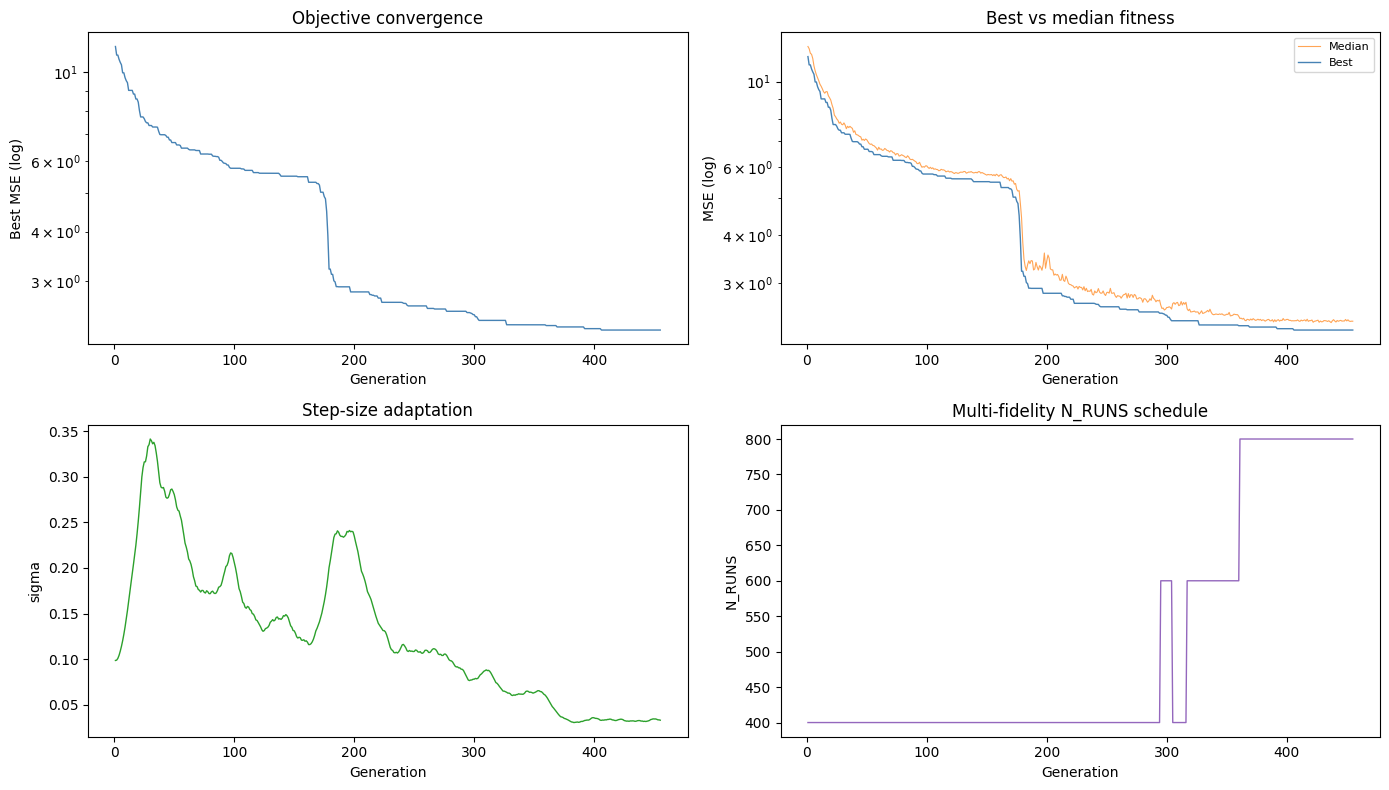

In [4]:
history = result["history"]
gens = np.array(history["gen"])

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Best objective
axes[0, 0].semilogy(gens, history["f_best"], "-", color="steelblue", lw=1)
axes[0, 0].set_xlabel("Generation")
axes[0, 0].set_ylabel("Best MSE (log)")
axes[0, 0].set_title("Objective convergence")

# Best vs median
axes[0, 1].semilogy(gens, history["f_median"], "-", color="tab:orange", lw=0.8, alpha=0.7, label="Median")
axes[0, 1].semilogy(gens, history["f_best"], "-", color="steelblue", lw=1, label="Best")
axes[0, 1].set_xlabel("Generation")
axes[0, 1].set_ylabel("MSE (log)")
axes[0, 1].set_title("Best vs median fitness")
axes[0, 1].legend(fontsize=8)

# Sigma
axes[1, 0].plot(gens, history["sigma"], "-", color="tab:green", lw=1)
axes[1, 0].set_xlabel("Generation")
axes[1, 0].set_ylabel("sigma")
axes[1, 0].set_title("Step-size adaptation")

# N_RUNS schedule
axes[1, 1].plot(gens, history["n_runs"], "-", color="tab:purple", lw=1)
axes[1, 1].set_xlabel("Generation")
axes[1, 1].set_ylabel("N_RUNS")
axes[1, 1].set_title("Multi-fidelity N_RUNS schedule")

plt.tight_layout()
plt.show()

## Results: D* and Signal Reconstruction

High-fidelity evaluation of the optimized dwell profile using CPU (for validation).

In [5]:
import os
from concurrent.futures import ThreadPoolExecutor

D_best = result["D_best"]

def run_single(args):
    dwell_profile, seed = args
    params = dict(base_params)
    params["RNAP_dwellTimeProfile"] = dwell_profile
    r = netseq_tasep_fast(params, seed=seed)
    return np.asarray(r["NETseq_sum"], dtype=float), np.asarray(r["flux"], dtype=float)

# High-fidelity: D* (300 runs)
print("Evaluating D* with 300 CPU runs...")
t0 = time.time()
args_list = [(D_best, 99000 + i) for i in range(300)]
with ThreadPoolExecutor(max_workers=os.cpu_count()) as ex:
    results_hifi = list(ex.map(run_single, args_list))
S_sim_best = np.mean([r[0] for r in results_hifi], axis=0)
j_sim = np.mean([r[1] for r in results_hifi], axis=0)
S_sim_best_norm = S_sim_best / np.mean(S_sim_best)
print(f"  Done in {time.time() - t0:.1f}s")

# High-fidelity: baseline (300 runs)
print("Evaluating baseline with 300 CPU runs...")
t0 = time.time()
args_list = [(S_exp_norm, 88000 + i) for i in range(300)]
with ThreadPoolExecutor(max_workers=os.cpu_count()) as ex:
    results_base = list(ex.map(run_single, args_list))
S_sim_baseline = np.mean([r[0] for r in results_base], axis=0)
S_sim_baseline_norm = S_sim_baseline / np.mean(S_sim_baseline)
print(f"  Done in {time.time() - t0:.1f}s")

mse_best = np.mean((S_exp_norm - S_sim_best_norm) ** 2)
mse_baseline = np.mean((S_exp_norm - S_sim_baseline_norm) ** 2)

print(f"\nHigh-fidelity comparison:")
print(f"  Baseline (D=S_exp):  MSE={mse_baseline:.6f}, RMS={np.sqrt(mse_baseline):.4f}")
print(f"  CMA-ES D*:           MSE={mse_best:.6f}, RMS={np.sqrt(mse_best):.4f}")
if mse_baseline > 0:
    print(f"  Improvement: {(1 - mse_best / mse_baseline) * 100:.1f}%")

Evaluating D* with 300 CPU runs...
  Done in 0.3s
Evaluating baseline with 300 CPU runs...
  Done in 0.3s

High-fidelity comparison:
  Baseline (D=S_exp):  MSE=12.403889, RMS=3.5219
  CMA-ES D*:           MSE=2.663670, RMS=1.6321
  Improvement: 78.5%


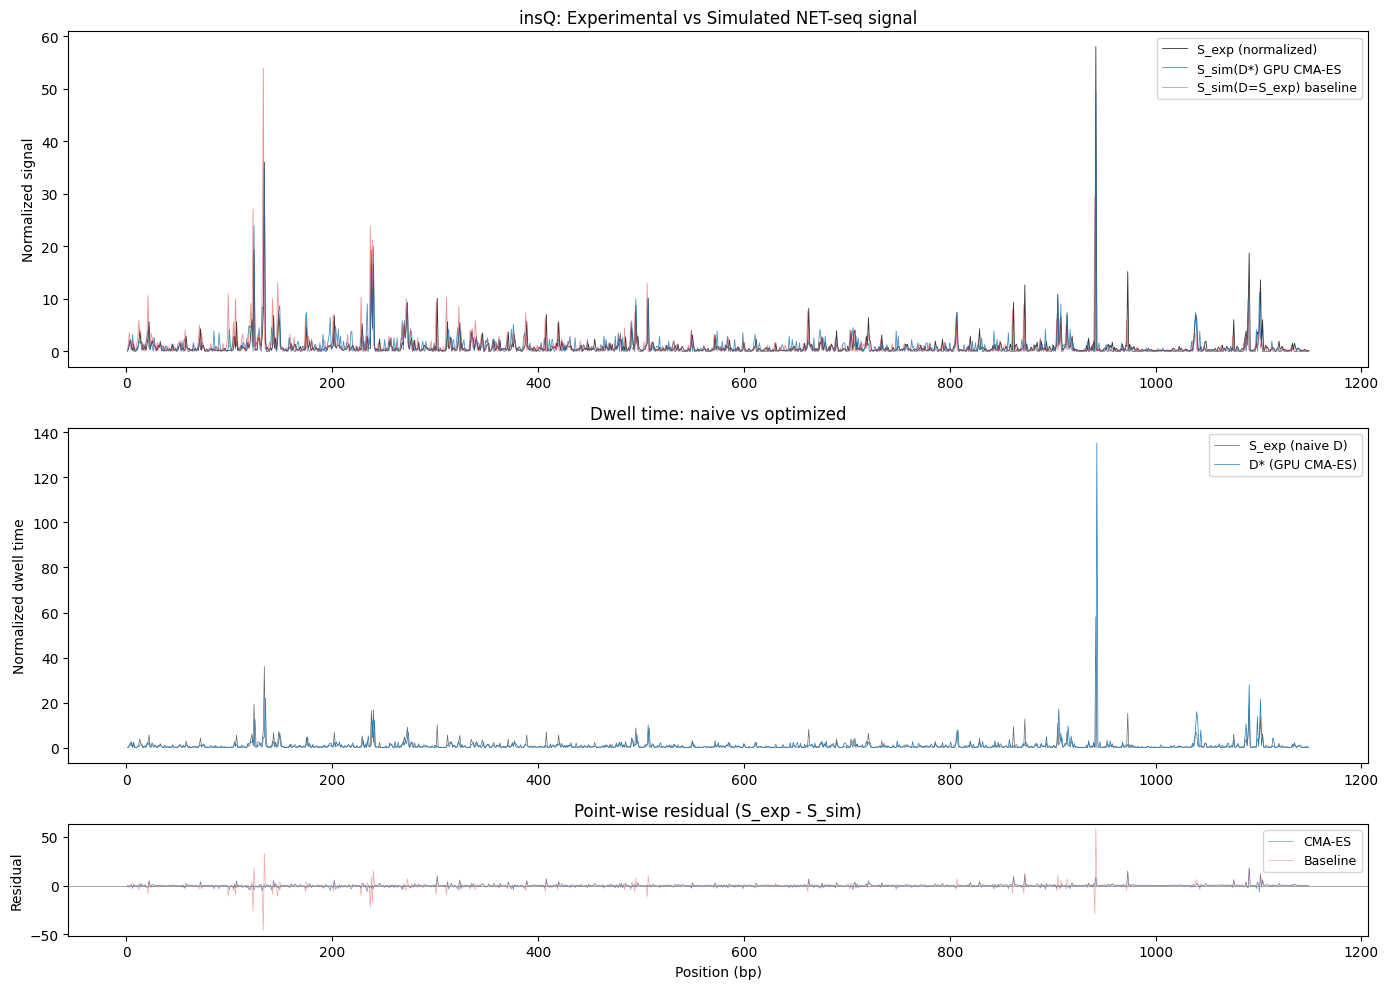

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 3, 1]})

# S_exp vs S_sim(D*) vs baseline
axes[0].plot(pos, S_exp_norm, lw=0.6, color="black", label="S_exp (normalized)", alpha=0.8)
axes[0].plot(pos, S_sim_best_norm, lw=0.6, color="tab:blue", label="S_sim(D*) GPU CMA-ES", alpha=0.8)
axes[0].plot(pos, S_sim_baseline_norm, lw=0.6, color="tab:red", label="S_sim(D=S_exp) baseline", alpha=0.5)
axes[0].set_ylabel("Normalized signal")
axes[0].set_title(f"{GENE}: Experimental vs Simulated NET-seq signal")
axes[0].legend(fontsize=9)

# D* vs S_exp
axes[1].plot(pos, S_exp_norm, lw=0.5, color="black", label="S_exp (naive D)", alpha=0.6)
axes[1].plot(pos, D_best, lw=0.5, color="tab:blue", label="D* (GPU CMA-ES)")
axes[1].set_ylabel("Normalized dwell time")
axes[1].set_title("Dwell time: naive vs optimized")
axes[1].legend(fontsize=9)

# Residuals
axes[2].plot(pos, S_exp_norm - S_sim_best_norm, lw=0.5, color="tab:blue", alpha=0.7, label="CMA-ES")
axes[2].plot(pos, S_exp_norm - S_sim_baseline_norm, lw=0.5, color="tab:red", alpha=0.4, label="Baseline")
axes[2].axhline(0, color="gray", ls="-", lw=0.5)
axes[2].set_xlabel("Position (bp)")
axes[2].set_ylabel("Residual")
axes[2].set_title("Point-wise residual (S_exp - S_sim)")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

## Implied Flux Profile

Compare simulated flux $j_\text{sim}(x)$ from TASEP with the flux approximation $j \approx S_\text{exp} / D^*$.

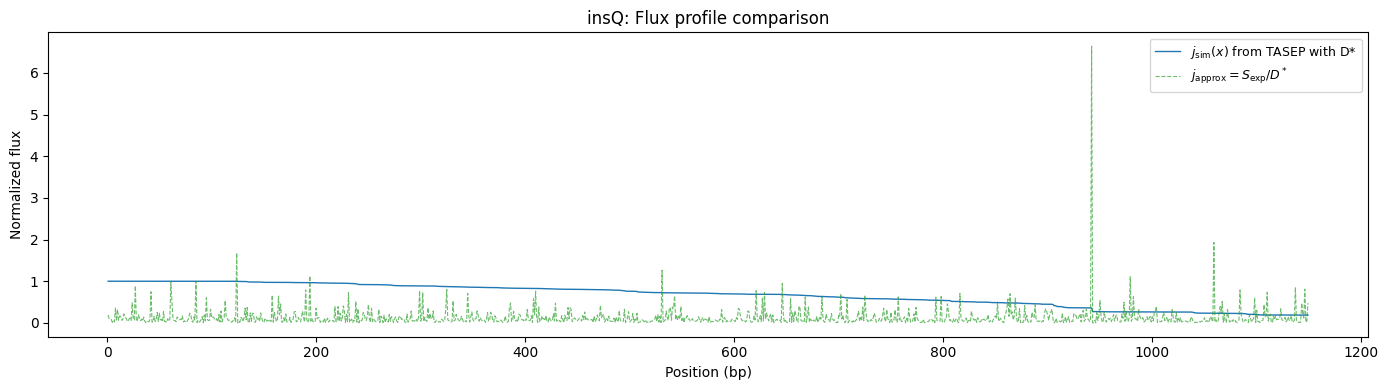

In [7]:
j_sim_norm = j_sim / np.max(j_sim[:100])
j_approx = S_exp_norm / np.maximum(D_best, 1e-6)
j_approx_norm = j_approx / np.max(j_approx[:100])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(pos, j_sim_norm, lw=1.0, color="tab:blue", label=r"$j_\mathrm{sim}(x)$ from TASEP with D*")
ax.plot(pos, j_approx_norm, lw=0.8, color="tab:green", ls="--", alpha=0.7,
        label=r"$j_\mathrm{approx} = S_\mathrm{exp} / D^*$")
ax.set_xlabel("Position (bp)")
ax.set_ylabel("Normalized flux")
ax.set_title(f"{GENE}: Flux profile comparison")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()